<link rel="stylesheet" href="notebook_theme.css">

# Optimization in PyTorch — Full Report

This notebook demonstrates:
- Regression with L1 vs no L1
- Logistic Regression (Softmax + CrossEntropy)
- Numerical stability
- Decision boundary visualization
- Mini Neural Network (1 hidden layer)


## Regression: L1 vs No L1

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
torch.manual_seed(42)

# Data
x = torch.randn(100, 1)
y = 2 * x + 1 + 0.1 * torch.randn(100, 1)

def train_model(l1_lambda=0.0):
    model = nn.Linear(1,1)
    optimizer = optim.SGD(model.parameters(), lr=0.1)
    criterion = nn.MSELoss()
    losses = []

    for epoch in range(100):
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)

        l1 = sum(p.abs().sum() for p in model.parameters())
        loss = loss + l1_lambda * l1

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        losses.append(loss.item())

    return losses

loss_no_l1 = train_model(0.0)
loss_l1 = train_model(0.01)

plt.figure()
plt.plot(loss_no_l1, label='No L1')
plt.plot(loss_l1, label='With L1')
plt.title('L1 vs No L1')
plt.legend()
plt.show()

## Logistic Regression + Decision Boundary

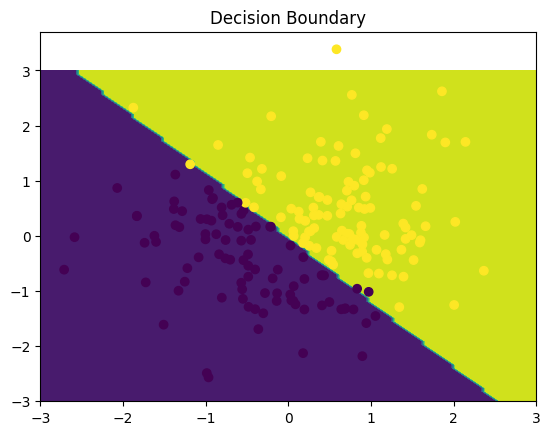

In [4]:
N = 200
X = torch.randn(N, 2)
y = (X[:,0] + X[:,1] > 0).long()

model = nn.Linear(2,2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()

for epoch in range(100):
    optimizer.zero_grad()
    logits = model(X)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()

# Decision boundary
xx, yy = np.meshgrid(np.linspace(-3,3,100), np.linspace(-3,3,100))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
preds = model(grid).argmax(dim=1).numpy().reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, preds)
plt.scatter(X[:,0], X[:,1], c=y)
plt.title('Decision Boundary')
plt.show()

## Mini Neural Network

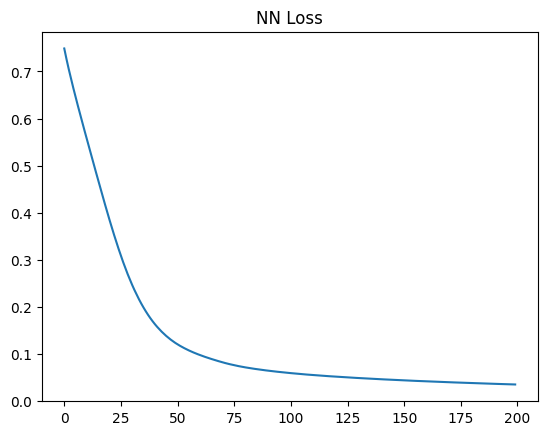

In [5]:
model = nn.Sequential(
    nn.Linear(2, 10),
    nn.ReLU(),
    nn.Linear(10, 2)
)

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

losses = []

for epoch in range(200):
    optimizer.zero_grad()
    logits = model(X)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure()
plt.plot(losses)
plt.title('NN Loss')
plt.show()